In [1]:
import rasterio
import rasterio.mask
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon, box
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
from reusable import *
import os, json

#### **Paths and Data**

Requires prepared OSM, gtfs, and population raster files. Can also include a city projection (optionally) or filter through relevant administrative boundaries later.

In [2]:
osm_path = 'cities\\torino\Turin.osm.pbf'
gtfs_path = 'cities\\torino\mdb-2687-202602270130.zip'
pop_path = r"D:\\hp\\ita_general_2020_geotiff\\ita_general_2020.tif"
#city_proj = gpd.read_file("cities/singapore/sg_boundary.zip")

In [3]:
tn = r5.TransportNetwork(osm_path, gtfs=gtfs_path)

#### **Boundaries + grid**

Filter from existing boundaries

In [ ]:
osm = OSM(osm_path)
boundaries = osm.get_boundaries()
boundaries.sort_values(by="admin_level", ascending=False).head(10)

In [22]:
torino = boundaries[
    (boundaries["boundary"] == "administrative") &
    (boundaries["admin_level"].astype(str) == "8") &
    (boundaries["name"].str.contains("Torin", case=False, na=False))
].copy()

In [ ]:
def keep_largest_connected_component(gdf):
    gdf = gdf.copy().reset_index(drop=True)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()

    sindex = gdf.sindex
    pairs = []

    for i, geom in enumerate(gdf.geometry):
        for j in sindex.query(geom, predicate="intersects"):
            if j <= i:
                continue
            other = gdf.geometry.iloc[j]
            if geom.touches(other) or geom.intersects(other):
                pairs.append((i, j))

    parent = list(range(len(gdf)))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b in pairs:
        union(a, b)

    labels = pd.Series([find(i) for i in range(len(gdf))], index=gdf.index)
    largest_component = labels.value_counts().idxmax()

    return gdf.loc[labels == largest_component].copy()

torino_clean = keep_largest_connected_component(torino)

Or load using local GeoJSON/Shapefile boundary

<Axes: >

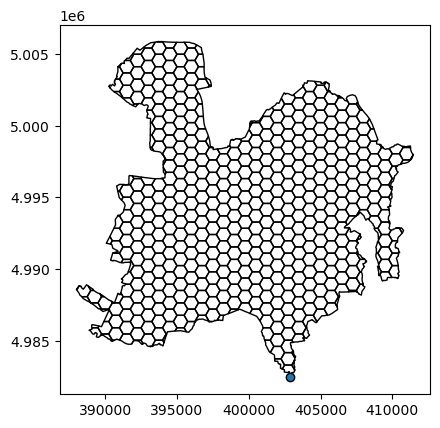

In [21]:
city_proj = torino_clean.copy()
city_proj = city_proj.dissolve()
city_proj = city_proj.to_crs(city_proj.estimate_utm_crs())
grid = create_hex_grid(city_proj, 500)
grid.plot(edgecolor='black', facecolor='none')

#### **Populating the grid**

Raster total population:  978,840
Hex grid total population: 978,551
Coverage: 100.0%


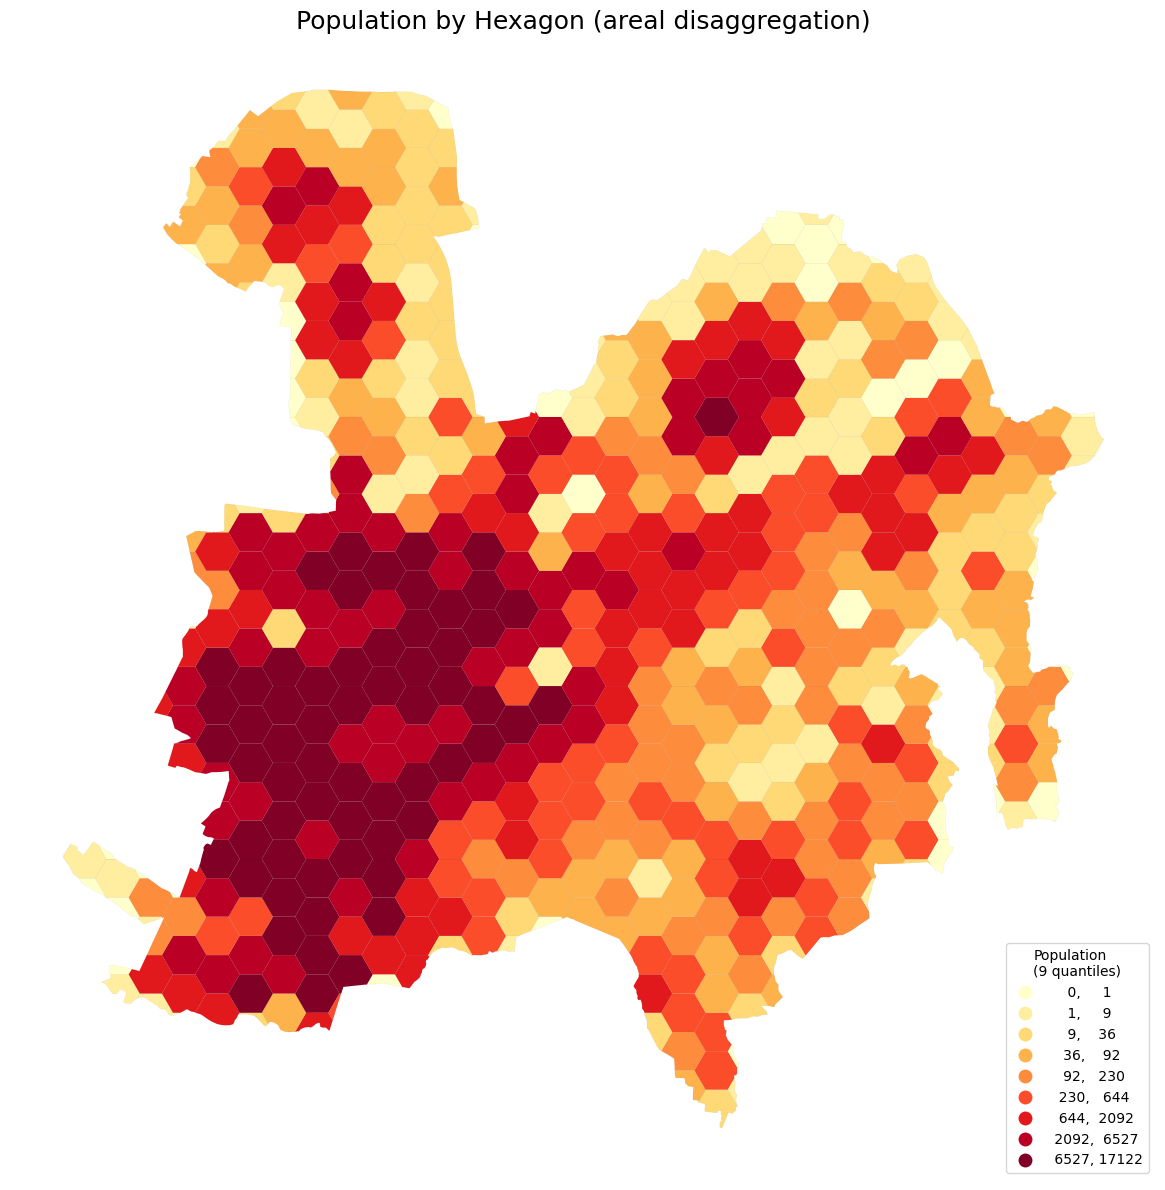

In [23]:
grid_pop = assign_population_to_grid(pop_path, grid, plot=True)

In [29]:
result_geo = build_city_geojson(
    grid=grid,
    grid_pop=grid_pop,
    osm=osm,
    tn=tn,
    output_path="data/turin_scores.geojson",
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=25,
    beta=0.0277,
    gravity_normalisation=100,
)

City-wide baseline distribution:
  count_community: 0.050
  count_education: 0.091
  count_essential_services: 0.104
  count_food_and_drink: 0.617
  count_healthcare: 0.126
  count_shelter: 0.011


#### **Origins**

In [13]:
origins = create_origins(grid, grid_pop)
origins.head(5)

,geometry,id,population
0,POINT (7.46464 44.93805),0,0.000000
1,POINT (7.46182 44.94367),1,9.275184
2,POINT (7.45355 44.94837),2,5.558048
3,POINT (7.46072 44.95093),3,17.497422
4,POINT (7.44538 44.95318),4,0.000000


#### **Destinations (POIs)**

In [14]:
destinations = create_POIs(osm, summary=True)

Total amenities: 10820

By type:
amenity class
food_and_drink        3730
drinking_water        1296
healthcare             959
education              902
community              711
essential_services     709
fuel                   462
charging_station       245
toilets                229
ice_cream              166


#### **Results and Visualisation**

Define categories of interest among the amenity classes to measure

In [ ]:
categories = ['food_and_drink','shelter','essential_services','education','healthcare','community']
essentials = destinations[destinations['amenity class'].isin(categories)]

Compute travel time matrix between all origins and points of interest, deifining threshold for max. travel time and modes of transport

In [17]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=essentials,
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=timedelta(minutes=25) #CUTOFF
)

Calculate score for basic metrics (minimum travel time, basic counts (no gravity), weighted counts (gravity))

In [18]:
min_tt_wide = min_travel_time(travel_time_matrix, essentials)

In [19]:
no_gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0)

In [20]:
gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0.0644)

Adjusting for population & diversity metric

In [21]:
pop_weighed = weight_pop(gravity, origins, score_cols=["gravity_food_and_drink"], normalisation=1000)

In [22]:
cols = [x for x in no_gravity.columns if x not in ['from_id','avg_gravity']]
diversity = compute_diversity_scores(no_gravity, count_cols=cols)

City-wide baseline distribution:
  gravity_community: 0.070
  gravity_education: 0.101
  gravity_essential_services: 0.108
  gravity_food_and_drink: 0.576
  gravity_healthcare: 0.130
  gravity_shelter: 0.014


### **Result Plotting**

In [23]:
gravity = merge_geometry(gravity, grid=grid)
res = merge_geometry(min_tt_wide, grid)
pop_weighed = merge_geometry(pop_weighed, grid)
no_gravity = merge_geometry(no_gravity, grid=grid)
diversity = merge_geometry(diversity, grid=grid)

In [24]:
def plot_hex_score(results_geo, score_col, from_id_col="from_id", scheme="Quantiles",
                   k=9, cmap="viridis", title=None, figsize=(14, 12),
                   legend_fmt="{:.1f}", ax=None, show=True):

    n_missing = results_geo[score_col].isna().sum()
    if n_missing > 0:
        print(f"Note: {n_missing} hexes have NaN for '{score_col}' and will appear grey.")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    results_geo.plot(
        column=score_col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        legend=True,
        linewidth=0.02,
        edgecolor="none",
        missing_kwds={"color": "lightgrey", "label": "No data"},
        legend_kwds={
            "loc": "upper left",
            "bbox_to_anchor": (1.02, 1),
            "fmt": legend_fmt
        },
        ax=ax
    )

    ax.set_title(title if title else score_col.replace("_", " ").title(), fontsize=18)
    ax.set_axis_off()

    if show:
        plt.tight_layout()
        plt.show()

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 9.
  self.bins = quantile(y, k=k)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 11.
  self.bins = quantile(y, k=k)


Note: 1101 hexes have NaN for 'min_tt_food_and_drink' and will appear grey.
Note: 782 hexes have NaN for 'avg_tt' and will appear grey.


d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting

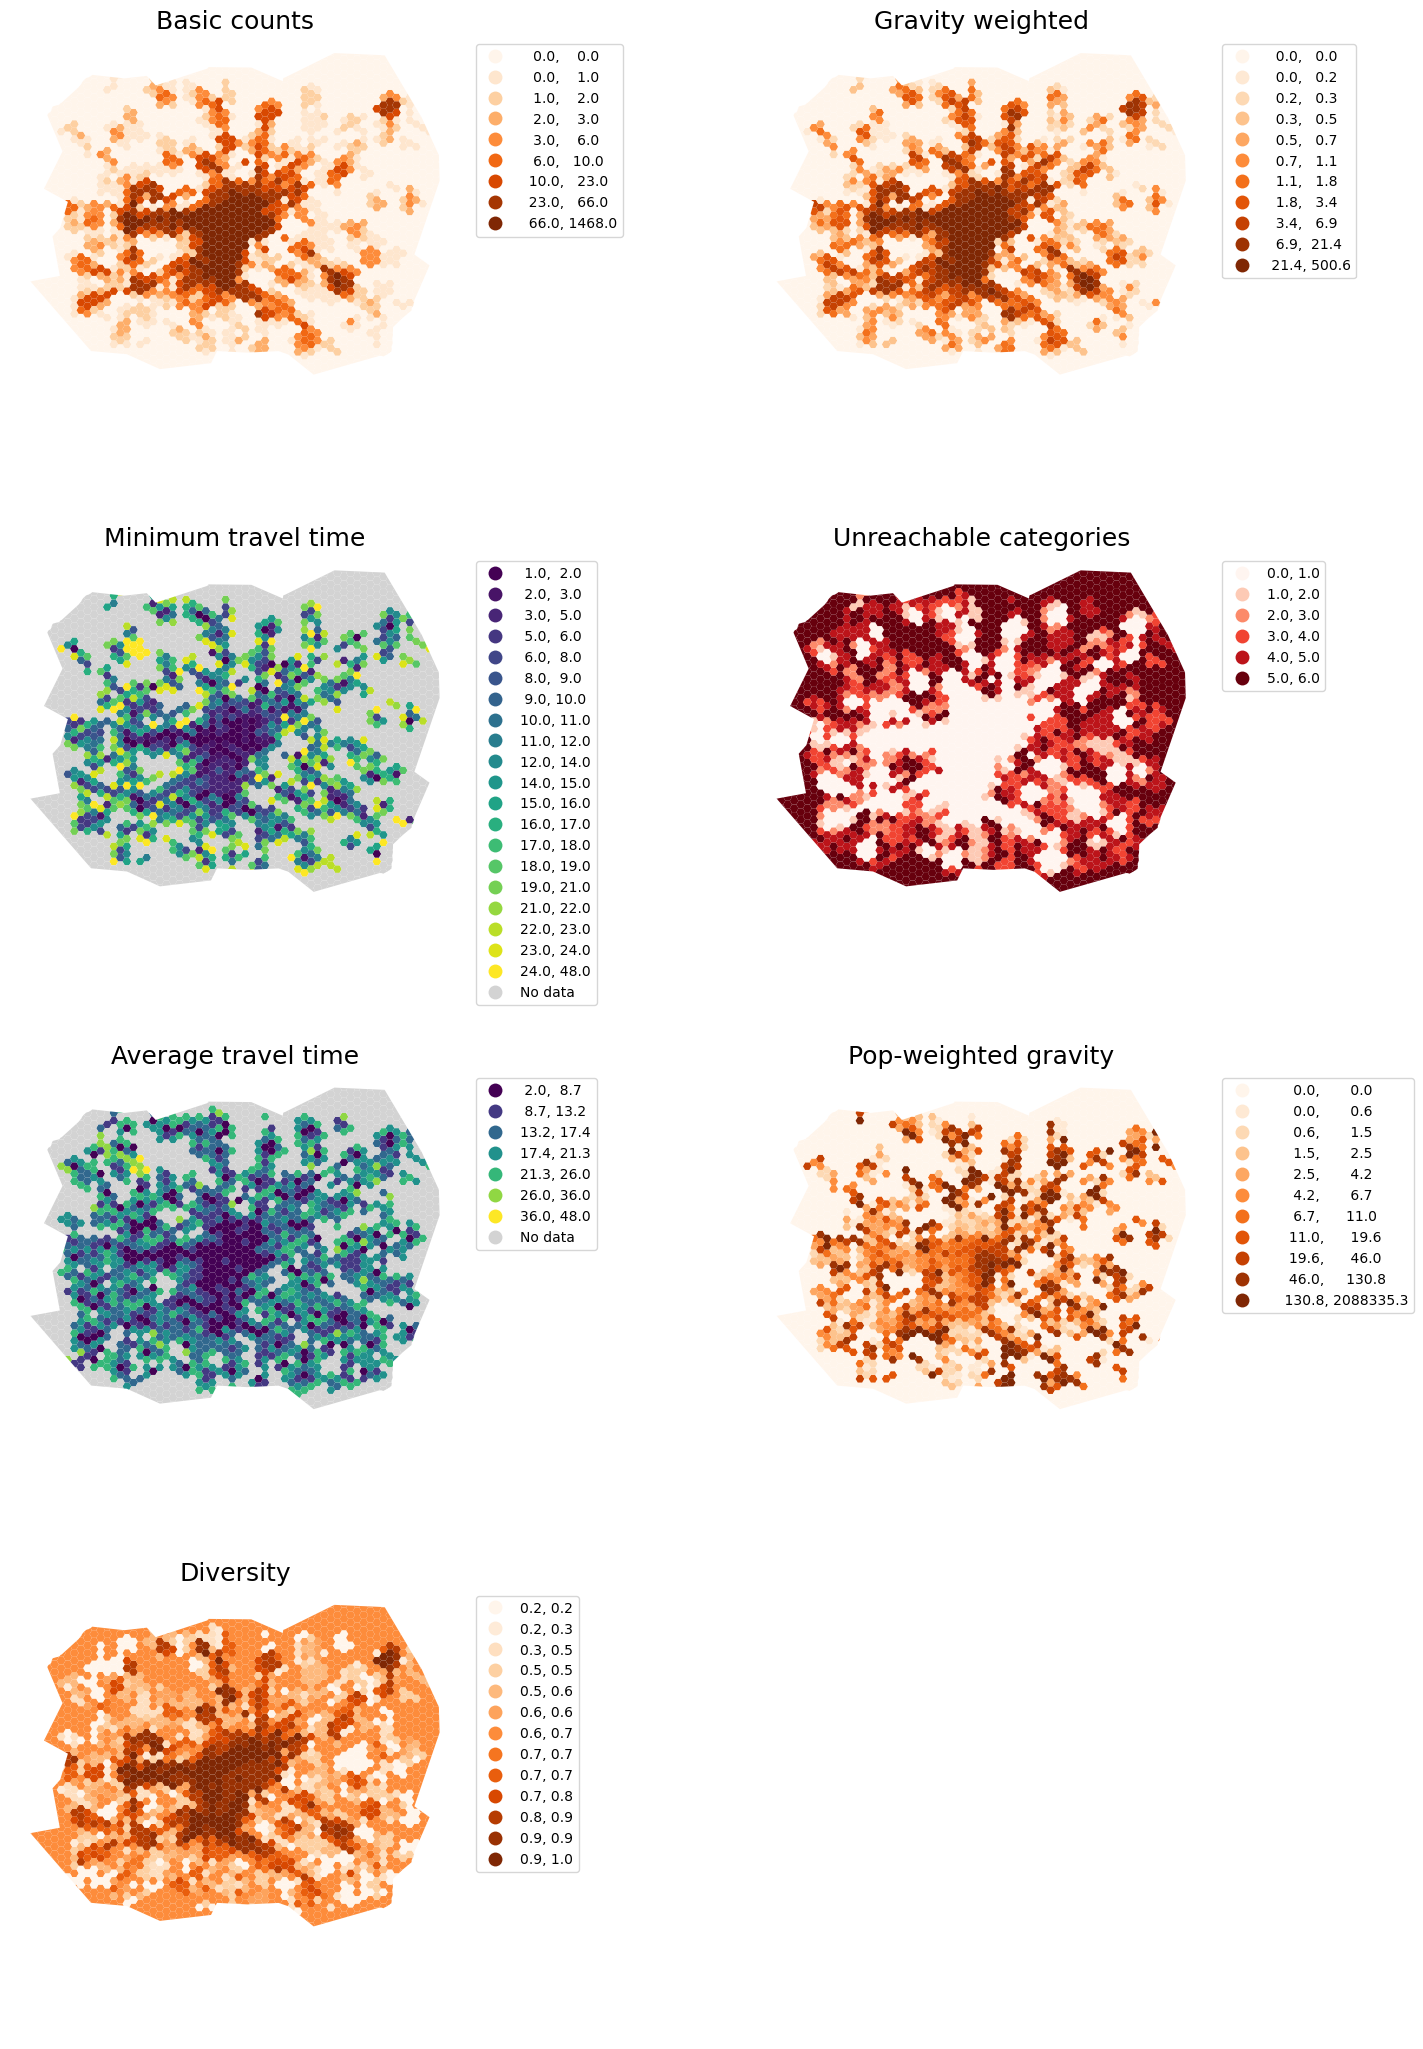

In [25]:
fig = plt.figure(figsize=(18, 26))
gs = fig.add_gridspec(
    nrows=8, ncols=2,
    height_ratios=[12, 1, 12, 1, 12, 1, 12, 1],
    hspace=0.35, wspace=0.15
)

plots = [
    (no_gravity, "gravity_food_and_drink", "Basic counts", "Oranges", "Quantiles", 20),
    (gravity, "gravity_food_and_drink", "Gravity weighted", "Oranges", "Quantiles", 20),
    (res, "min_tt_food_and_drink", "Minimum travel time", "viridis", "Quantiles", 20),
    (res, "n_unreachable_categories", "Unreachable categories", "Reds", "EqualInterval", 6),
    (res, "avg_tt", "Average travel time", "viridis", "NaturalBreaks", 7),
    (pop_weighed, "gravity_food_and_drink_per_1000", "Pop-weighted gravity", "Oranges", "Quantiles", 20),
    (diversity, "city_similarity", "Diversity", "Oranges", "Quantiles", 20),
]

for i, (gdf, col, ttl, cmap, scheme, k) in enumerate(plots):
    row = (i // 2) * 2
    col_idx = i % 2

    ax = fig.add_subplot(gs[row, col_idx])

    plot_hex_score(
        gdf,
        score_col=col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        title=ttl,
        ax=ax,
        show=False
    )

if len(plots) % 2 == 1:
    fig.add_subplot(gs[6, 1]).axis("off")
    fig.add_subplot(gs[7, 1]).axis("off")

plt.tight_layout()
fig.savefig("turin_results.png", dpi=300, bbox_inches="tight")